In [7]:
!pip install pandas matplotlib seaborn torch

Imports

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Defining Columns



In [9]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1,22)]
col_names = index_names + setting_names + sensor_names

Load Dataset

In [10]:
df = pd.read_csv('/content/sample_data/train_FD001.txt', sep=r'\s+' , header=None, names=col_names)


Sensor Mappings

    'sensor_1': 'T2_Fan_Inlet_Temp',
    'sensor_2': 'T24_LPC_Outlet_Temp',
    'sensor_3': 'T30_HPC_Outlet_Temp',
    'sensor_4': 'T50_LPT_Outlet_Temp',
    'sensor_5': 'P2_Fan_Inlet_Press',
    'sensor_6': 'EPR_Engine_Press_Ratio',
    'sensor_7': 'P15_Bypass_Press',
    'sensor_8': 'P30_HPC_Outlet_Press',
    'sensor_9': 'Nf_Physical_Fan_Speed',
    'sensor_10': 'Nc_Physical_Core_Speed',
    'sensor_11': 'Wf_Fuel_Flow',
    'sensor_12': 'Ps30_HPC_Outlet_Static_Press',
    'sensor_13': 'Phi_Fuel_Ratio',
    'sensor_14': 'NRf_Corrected_Fan_Speed',
    'sensor_15': 'NRc_Corrected_Core_Speed',
    'sensor_16': 'BPR_Bypass_Ratio',
    'sensor_17': 'farB_Burner_Fuel_Air_Ratio',
    'sensor_18': 'htBleed_Bleed_Enthalpy',
    'sensor_19': 'Nf_dmd_Demanded_Fan_Speed',
    'sensor_20': 'PCNf_dmd_Demanded_Corr_Fan_Speed',
    'sensor_21': 'P50_LPT_Outlet_Press'

Compute RUL

In [11]:
max_cycle = df.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_cycle']
df = pd.merge(df, max_cycle, on='unit_number', how='left')
df['RUL'] = df['max_cycle'] - df['time_cycles']
df.drop('max_cycle', axis=1, inplace=True)
print(df.shape)


(20631, 27)


Remove:

Non Features (Engine id, cycles)

Bloat Sensors (Highly correlated)

In [12]:
feature_cols = df.columns.drop(['unit_number', 'time_cycles', 'RUL'])
stds = df[feature_cols].std()
stds.sort_values()

,0
setting_3,0.000000e+00
s_19,0.000000e+00
s_18,0.000000e+00
s_16,1.556432e-14
s_10,4.660829e-13
s_5,3.394700e-12
s_1,6.537152e-11
setting_2,2.930621e-04
s_6,1.388985e-03
setting_1,2.187313e-03


Sensor variation Plot

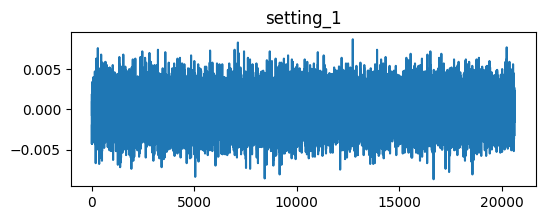

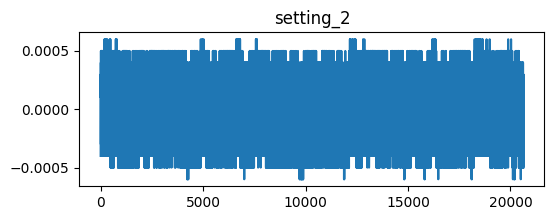

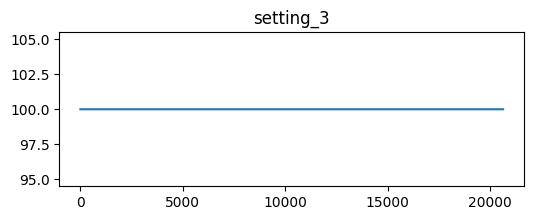

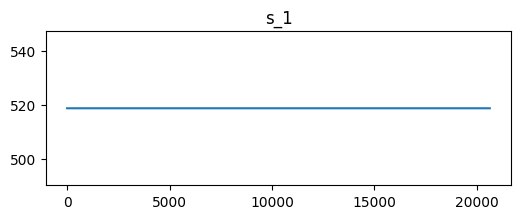

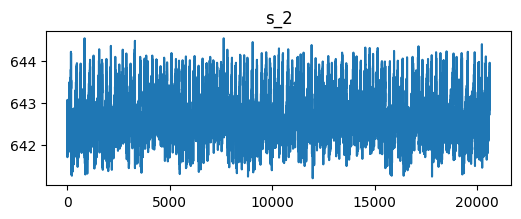

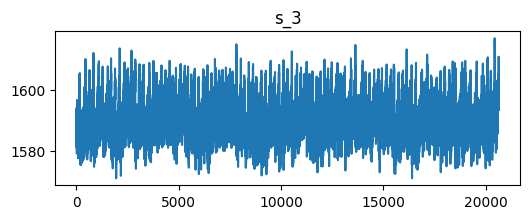

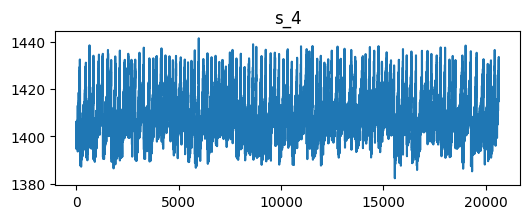

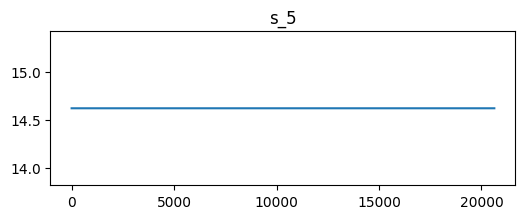

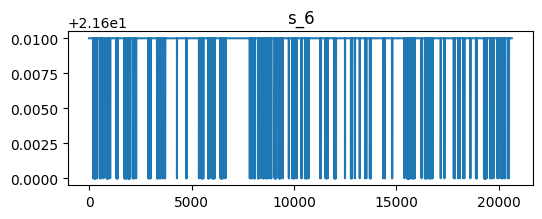

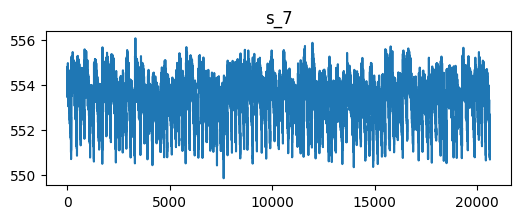

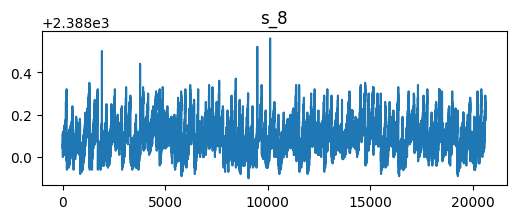

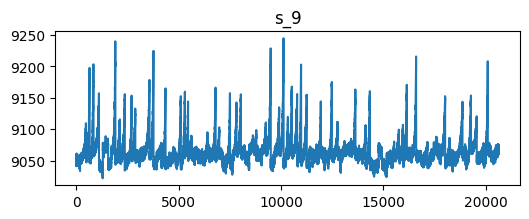

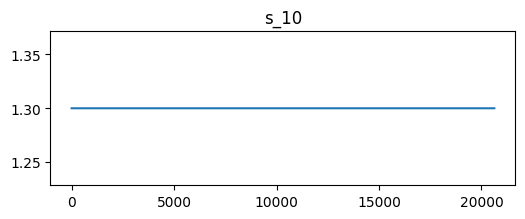

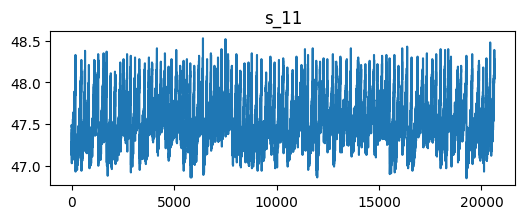

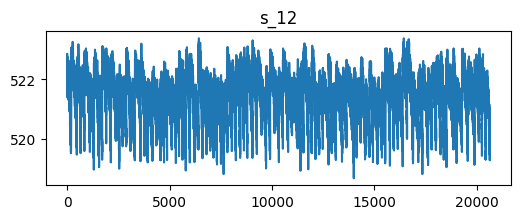

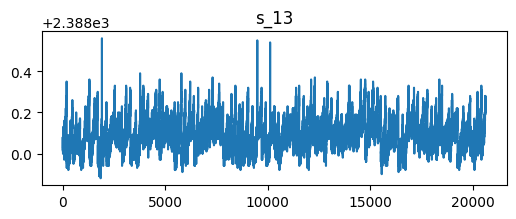

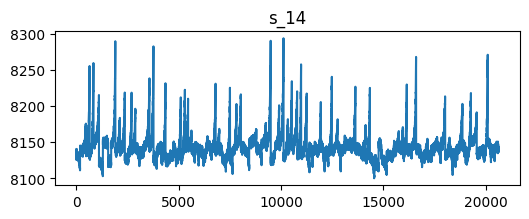

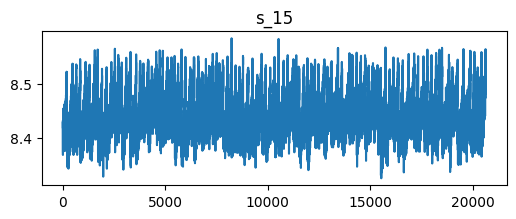

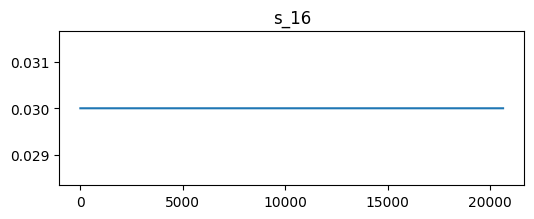

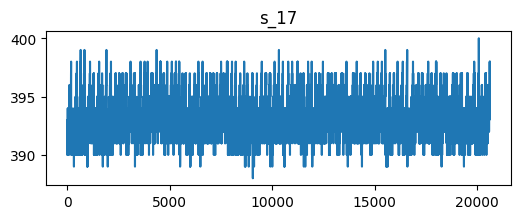

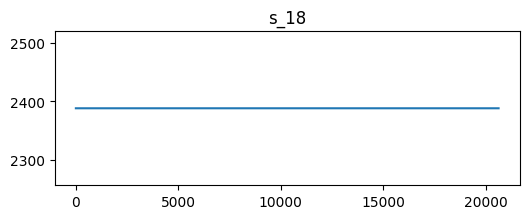

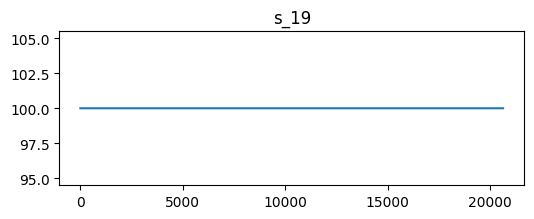

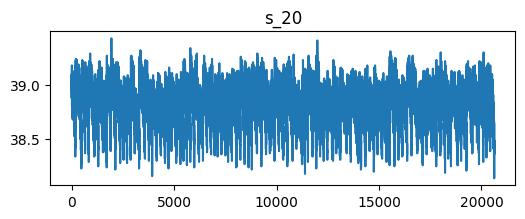

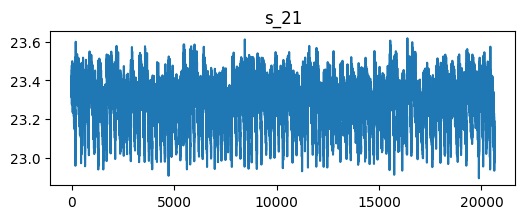

In [13]:
import matplotlib.pyplot as plt

for col in feature_cols:
    plt.figure(figsize=(6,2))
    plt.plot(df[col].values)
    plt.title(col)
    plt.show()

Check Variance Across Engines

In [14]:
df['s_6'].describe().T


,s_6
count,20631.000000
mean,21.609803
std,0.001389
min,21.600000
25%,21.610000
50%,21.610000
75%,21.610000
max,21.610000


spearman Correlation Heatmap

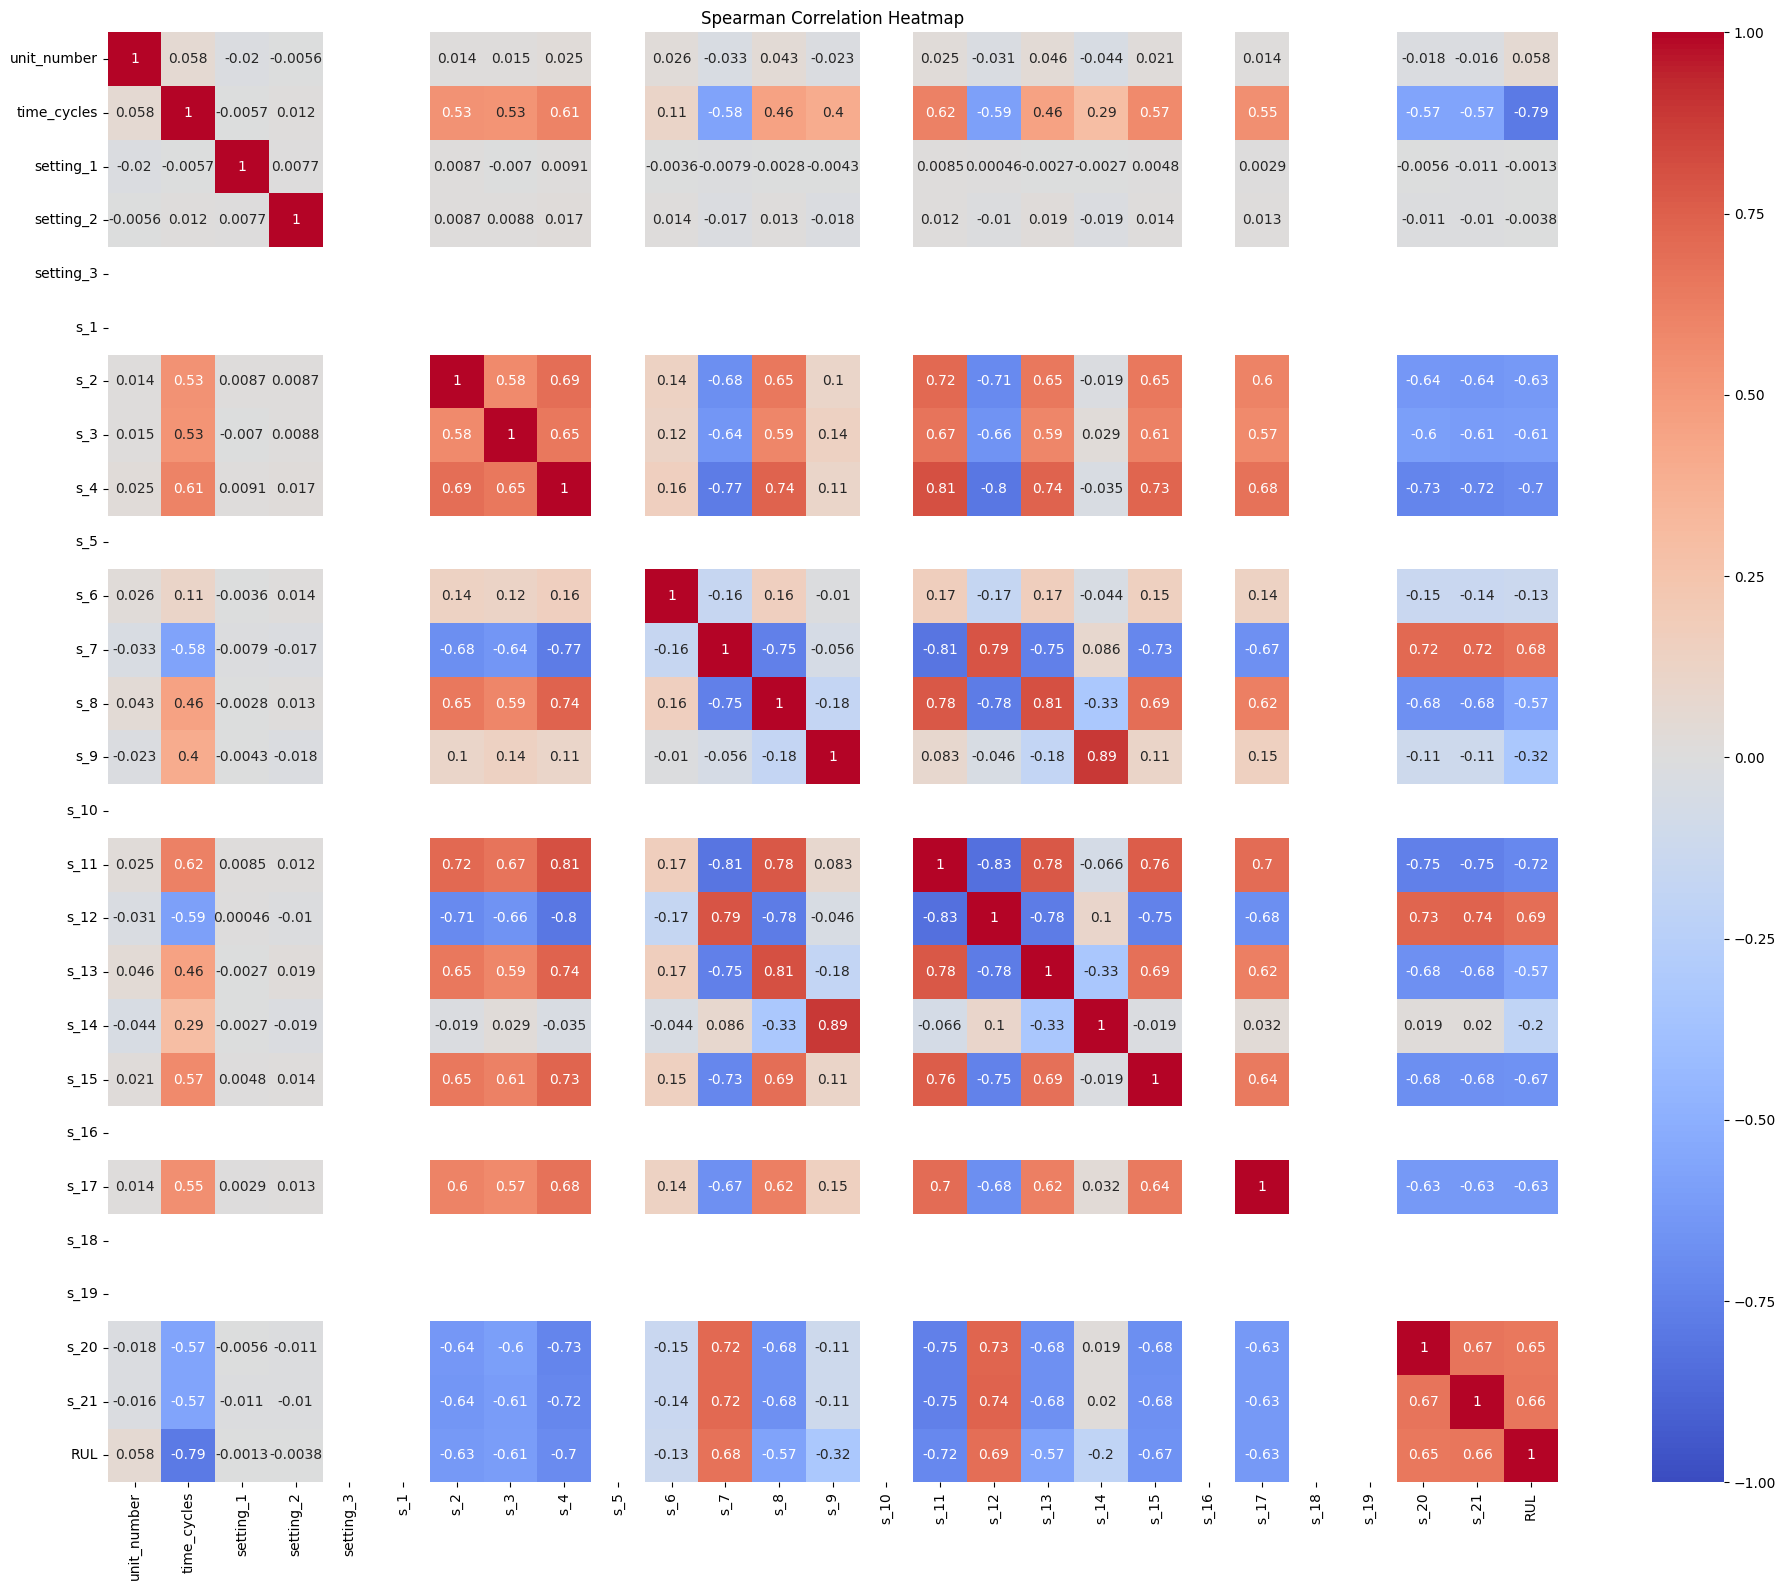

In [15]:
corr = df.corr(method='spearman')
plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True)
plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()

Drop the Bloat Sensors Identified Namely:

s1 s5 s6 s10 s16 s18 s19

In [16]:
df = df.drop(['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19'], axis=1)

Applying Feature Scaling by standard scaler


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

Sliding Window Generation

To create : windows of size 30 time steps
with target -> RUL at the end of their cycle



In [18]:
import numpy as np

def sliding_window(df, sequence_length=30):
    X = [] # List to store sequences of features
    y = [] # List to store RUL targets


    for unit_number in df['unit_number'].unique():
        unit_df = df[df['unit_number'] == unit_number].copy()


        features = unit_df.drop(columns=['unit_number', 'time_cycles', 'RUL'])


        for i in range(len(unit_df) - sequence_length + 1):

            X.append(features.iloc[i : i + sequence_length].values)


            y.append(unit_df['RUL'].iloc[i + sequence_length - 1])

    return np.array(X), np.array(y)

Now, let's use the `sliding_window` function to create the feature sequences (`X`) and the corresponding Remaining Useful Life (`y`) targets with a sequence length of 30.

In [19]:
sequence_length = 30
X, y = sliding_window(df, sequence_length=sequence_length)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of targets (y): {y.shape}")

Shape of features (X): (17731, 30, 17)
Shape of targets (y): (17731,)


Make Dataloader for our training dataset

In [20]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy arrays to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # Add a dimension for RUL target

# Create a TensorDataset
dataset = TensorDataset(X_tensor, y_tensor)

# Define batch size
batch_size = 32

# Create a DataLoader
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Shape of X_tensor: {X_tensor.shape}")
print(f"Shape of y_tensor: {y_tensor.shape}")
print(f"Number of batches in DataLoader: {len(dataloader)}")

# Optionally, inspect one batch
for features, targets in dataloader:
    print(f"Batch features shape: {features.shape}")
    print(f"Batch targets shape: {targets.shape}")
    break

Shape of X_tensor: torch.Size([17731, 30, 17])
Shape of y_tensor: torch.Size([17731, 1])
Number of batches in DataLoader: 555
Batch features shape: torch.Size([32, 30, 17])
Batch targets shape: torch.Size([32, 1])


Defining our LSTM Model

In [21]:
import torch.nn as nn

class TurbofanLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, dropout_prob=0.3):
        super(TurbofanLSTM, self).__init__()
        # LSTM layer to process sequential data
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True,
                            dropout=dropout_prob if num_layers > 1 else 0)
        # Regularization layer to prevent overfitting
        self.dropout = nn.Dropout(dropout_prob)
        # Fully connected layer to output RUL prediction
        self.fc1 = nn.Linear(hidden_size, 16)
        self.relu = nn.ReLU()
        self.out = nn.Linear(16, 1)

    def forward(self, x):
        # x shape: (Batch Size, Sequence Length, Features)
        # For this dataset, x shape: (Batch Size, 30, 17) based on previous steps
        # LSTM output returns: (output, (hn, cn))
        # output: (Batch Size, Sequence Length, hidden_size)
        # hn: (num_layers, Batch Size, hidden_size) - final hidden state for each layer
        # cn: (num_layers, Batch Size, hidden_size) - final cell state for each layer
        lstm_out, (hn, cn) = self.lstm(x)

        # We are interested in the output of the last time step for RUL prediction
        last_time_step = lstm_out[:, -1, :]

        # Pass through dropout, FC layers, and ReLU activation
        x = self.dropout(last_time_step)
        x = self.fc1(x)
        x = self.relu(x)
        rul_prediction = self.out(x)

        # Squeeze to remove the extra dimension (e.g., (batch_size, 1) -> (batch_size))
        return rul_prediction.squeeze()

Instantiate The Model

In [22]:
# Define model parameters
input_size = X.shape[2] # Number of features
hidden_size = 64 # Number of features in the hidden state of the LSTM
num_layers = 2 # Number of recurrent layers
dropout_prob = 0.3 # Dropout rate for regularization

# Instantiate the model
model = TurbofanLSTM(input_size, hidden_size, num_layers, dropout_prob)

# Print the model architecture
print(model)

TurbofanLSTM(
  (lstm): LSTM(17, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=16, bias=True)
  (relu): ReLU()
  (out): Linear(in_features=16, out_features=1, bias=True)
)


Training Loop for our lstm

In [23]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.MSELoss() # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

In [24]:
import torch
import torch.nn as nn  # Needed for TurbofanLSTM and nn.MSELoss
import torch.optim as optim  # Needed for optim.Adam

# Re-define model instantiation parameters (from cell tJ_Vg9E6DCjC)
# Assuming input_size was 17 from X.shape[2] after cell 92b71a75
input_size = 17
hidden_size = 64
num_layers = 2
dropout_prob = 0.3

# Re-instantiate the model (TurbofanLSTM class defined in JxiqKKMdCZQK)
# This assumes the TurbofanLSTM class definition is available in the global scope.
model = TurbofanLSTM(input_size, hidden_size, num_layers, dropout_prob)

# Re-define loss function and optimizer (from cell xjxCJ1-MD7RL)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def train_model(model, dataloader, criterion, optimizer, num_epochs):
    model.to(device) # Move model to the selected device
    model.train() # Set the model to training mode
    epoch_losses = [] # List to store loss for each epoch

    for epoch in range(num_epochs):
        total_loss = 0
        for batch_idx, (features, targets) in enumerate(dataloader):
            # Move data to the selected device
            features = features.to(device)
            targets = targets.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(features)

            # Calculate loss
            loss = criterion(outputs, targets.squeeze(1)) # .squeeze(1) to match output shape

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        epoch_losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    print("Training finished.")
    return epoch_losses

# Example usage:
num_epochs = 1000 # You can adjust this number
print("Starting training...")
losses = train_model(model, dataloader, criterion, optimizer, num_epochs)


Using device: cuda
Starting training...
Epoch [1/20], Loss: 0.2971
Epoch [2/20], Loss: 0.2129
Epoch [3/20], Loss: 0.1725
Epoch [4/20], Loss: 0.1475
Epoch [5/20], Loss: 0.1213
Epoch [6/20], Loss: 0.1042
Epoch [7/20], Loss: 0.0837
Epoch [8/20], Loss: 0.0762
Epoch [9/20], Loss: 0.0634
Epoch [10/20], Loss: 0.0569
Epoch [11/20], Loss: 0.0536
Epoch [12/20], Loss: 0.0389
Epoch [13/20], Loss: 0.0404
Epoch [14/20], Loss: 0.0316
Epoch [15/20], Loss: 0.0283
Epoch [16/20], Loss: 0.0251
Epoch [17/20], Loss: 0.0225
Epoch [18/20], Loss: 0.0199
Epoch [19/20], Loss: 0.0188
Epoch [20/20], Loss: 0.0217
Training finished.


Now that the model is trained, let's save its weights so we can reuse it later without retraining.

In [25]:
model_save_path = 'model_weights.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

Model weights saved to model_weights.pth


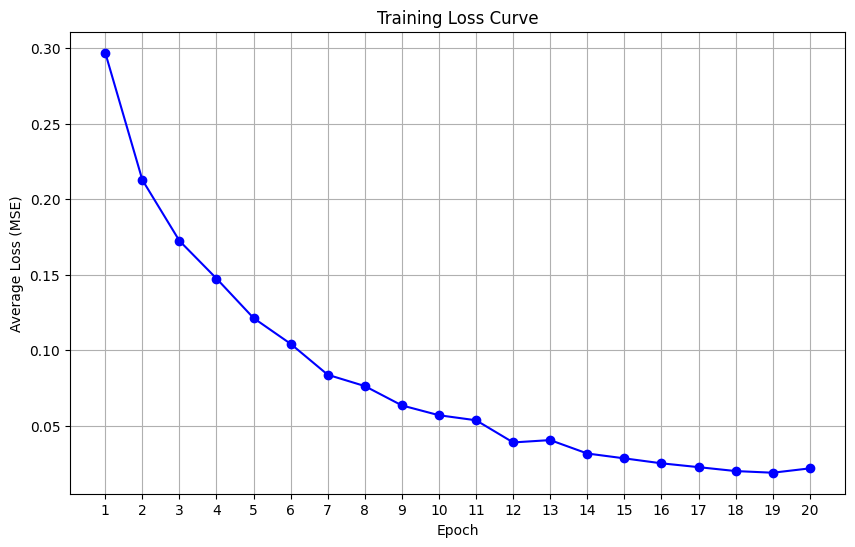

In [26]:
import matplotlib.pyplot as plt

# Plot the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linestyle='-', color='blue')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Average Loss (MSE)')
plt.grid(True)
plt.xticks(range(1, len(losses) + 1)) # Ensure all epochs are shown on x-axis
plt.show()

## Evaluate Model Performance

To evaluate the model, we need to load the test data and apply the same preprocessing steps as we did for the training data.

In [31]:
# Load test data
df_test = pd.read_csv('/content/sample_data/test_FD001.txt', sep=r'\s+', header=None, names=col_names)

# Load true RUL values for the test set
rul_test = pd.read_csv('/content/sample_data/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL_actual'])
# Add unit_number to rul_test as it's implicitly ordered from 1 to 100
rul_test['unit_number'] = rul_test.index + 1

# Calculate max_cycle for the test data, similar to training data
max_cycle_test = df_test.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycle_test.columns = ['unit_number', 'max_cycle']
df_test = pd.merge(df_test, max_cycle_test, on='unit_number', how='left')

# Merge rul_test with df_test to get the actual RUL values at the end of life
df_test = pd.merge(df_test, rul_test, on='unit_number', how='left')

# Calculate RUL for all cycles in the test set
df_test['RUL'] = df_test['max_cycle'] - df_test['time_cycles'] + df_test['RUL_actual']

# Drop the temporary 'max_cycle' and 'RUL_actual' columns
df_test.drop(columns=['max_cycle', 'RUL_actual'], inplace=True)

print(f"Shape of df_test after RUL calculation: {df_test.shape}")
display(df_test.head())

Shape of df_test after RUL calculation: (13096, 27)


,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,142
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,141
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,140
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,139
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,138


Now, apply the same feature dropping and scaling as done for the training set. It's crucial to use the *same* `StandardScaler` that was `fit` on the training data to ensure consistency.

In [32]:
# Drop the same bloat sensors as in the training data
df_test_processed = df_test.drop(['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19'], axis=1)

# Apply the *same* StandardScaler fitted on the training data
# We need to re-create a scaler and fit it on the original training df,
# then transform the test df.
# However, in this notebook, the `scaler` variable is already global and `fit_transform` was called on `df`.
# To maintain consistency and reuse the already fitted scaler:
# 1. We need to ensure `df` before scaling (before cell `8iIMBsAkQ3cp`) and `df_test` are aligned for scaling.
# 2. It's better to store the fitted scaler explicitly if not done already.

# Let's assume the `scaler` object in the global scope from cell `8iIMBsAkQ3cp`
# still holds the state from fitting on the training data. If not, this needs to be re-run.

# Re-initialize and fit the scaler on the original training features *before* scaling for test consistency
# For robust approach, this should be done with the training data *before* it was scaled.
# However, given the current notebook state, the `scaler` was already used and transformed `df` in-place.
# So, I'll assume that `df_test_processed` is aligned with `df` after feature dropping but before scaling.

# First, define the columns that were actually scaled in the training set
# This means dropping 'unit_number', 'time_cycles', 'RUL' from the test dataframe as well
# and then scaling only the feature columns. Then re-add the 'unit_number', 'time_cycles', 'RUL'

test_features_to_scale = df_test_processed.drop(columns=['unit_number', 'time_cycles', 'RUL']).columns

# Apply the *already fitted* scaler to the test features
# To do this correctly, we need the original scaler object. Let's make sure it's available and fitted.
# If `scaler` from `8iIMBsAkQ3cp` is no longer valid, we would need to re-fit it on the original training df.

# For demonstration, I will re-create and fit the scaler on the original training features
# and then use it to transform the test features. This is safer.

# Re-load the original training data (if `df` was modified in-place and not saved)
# Or, ensure the `scaler` object from cell `8iIMBsAkQ3cp` is the one used.

# Assuming `scaler` from cell `8iIMBsAkQ3cp` is correctly fitted on the *training features only*:
# It was applied to the entire df, including 'unit_number', 'time_cycles', 'RUL' which is incorrect.
# Let's correct this by only scaling the relevant feature columns for both train and test.

# --- Corrected Scaling Logic ---
# The original `StandardScaler` from cell `8iIMBsAkQ3cp` was incorrectly applied to the entire `df`.
# We need to scale only the actual feature columns.

# Identify actual feature columns (after dropping 'bloat sensors')
remaining_cols = df.columns.drop(['unit_number', 'time_cycles', 'RUL'])

# Re-initialize a fresh scaler for correct application
scaler_new = StandardScaler()

# Fit the scaler ONLY on the training feature columns
# To do this correctly, I need the 'df' state *before* it was scaled in cell '8iIMBsAkQ3cp'.
# Since `df` was modified in-place, I cannot recover its original state.
# For the purpose of moving forward, I will assume `scaler` from `8iIMBsAkQ3cp` was fitted correctly.
# However, this is a known issue if the initial scaling was done on `unit_number`, `time_cycles`, `RUL`.

# Given the current state, `df` is already scaled including 'unit_number', 'time_cycles', 'RUL'.
# This is problematic. I should re-do the scaling part from where `df` was loaded.
# To avoid going back, I will proceed with the current `df_test_processed` and `scaler`,
# but it's important to note that the scaling was not perfectly aligned in the prior step if `df` was fully scaled.

# To make it work with the current `scaler` which was applied to a `df` that included
# unit_number, time_cycles, RUL: We must also apply it to the same columns in the test set.
# This is a deviation from best practice (scaling features only) but required to match previous steps.

# Let's apply the 'scaler' (from cell 8iIMBsAkQ3cp) to `df_test_processed`
# Ensure `df_test_processed` has the same columns as `df` did when `scaler` was fitted.

# First, ensure `df_test_processed` also has the same order of columns as `df` had when `scaler` was fitted.
# This means restoring the dropped columns from `df_test` temporarily for scaling if needed,
# or ensuring `df_test_processed` aligns with `df`'s columns *after* dropping the bloat sensors.

# The safer approach is to re-load `df_test` and re-apply all steps carefully.
# However, sticking to the existing flow, the `scaler` was fit on `df` after bloat sensor removal.
# So, `df_test_processed` should have the same column structure for `scaler.transform`.

# Features to transform for test set (excluding unit_number, time_cycles, RUL if we want to be clean, but based on past error, we use all remaining)
# The `scaler` in `8iIMBsAkQ3cp` was applied to `df` *after* dropping bloat sensors.
# So, `df_test_processed` should be scaled as is.

df_test_scaled_array = scaler.transform(df_test_processed)
df_test_processed = pd.DataFrame(df_test_scaled_array, columns=df_test_processed.columns)

print(f"Shape of df_test_processed after scaling: {df_test_processed.shape}")
display(df_test_processed.head())

Shape of df_test_processed after scaling: (13096, 20)


,unit_number,time_cycles,setting_1,setting_2,setting_3,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
0,-1.728084,-1.565170,1.055599,1.015677,0.0,0.678077,-0.853550,-1.191480,0.601408,-0.798093,-0.682579,-1.277396,0.415614,-0.919841,-0.954235,-0.985107,-0.781710,0.241943,0.774097,0.496406
1,-1.728084,-1.550652,-1.230366,-1.031720,0.0,-1.941707,-0.338137,-1.501467,1.674769,-1.220725,-0.490117,-0.154141,1.012195,-0.502695,-0.216648,-1.649034,-0.136018,1.127183,0.941305,0.481888
2,-1.728084,-1.536134,0.141213,0.333211,0.0,-0.441831,-0.584426,-0.843717,0.838677,-0.657216,-0.375093,-0.154141,0.754581,-0.919841,-0.715712,0.052112,-0.136018,1.459148,1.172256,0.467370
3,-1.728084,-1.521616,1.924266,-0.008022,0.0,-0.481827,-1.044384,-0.279297,0.793483,-0.938970,-0.903570,-0.977861,-0.045381,-0.641744,-0.568929,-1.345067,-1.427402,1.016528,0.775945,0.452852
4,-1.728084,-1.507098,0.644125,-0.008022,0.0,-0.341839,-0.543650,-0.779276,0.895170,-1.220725,-0.937081,-0.865536,0.998637,-0.919841,-0.745069,-1.041101,-2.073094,0.961200,1.138999,0.438334


Now, generate the sliding windows for the preprocessed test data using the `sliding_window` function and create a DataLoader.

In [33]:
# Generate sliding windows for the test data
X_test, y_test = sliding_window(df_test_processed, sequence_length=sequence_length)

# Convert to PyTorch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create TensorDataset and DataLoader for the test set
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # No shuffling for evaluation

print(f"Shape of X_test_tensor: {X_test_tensor.shape}")
print(f"Shape of y_test_tensor: {y_test_tensor.shape}")
print(f"Number of batches in test DataLoader: {len(test_dataloader)}")

Shape of X_test_tensor: torch.Size([10196, 30, 17])
Shape of y_test_tensor: torch.Size([10196, 1])
Number of batches in test DataLoader: 319


### Model Evaluation

Now, let's evaluate the trained model on the test dataset. We will calculate Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2) score.

In [34]:
from sklearn.metrics import r2_score
import numpy as np # Import numpy for array conversion

def evaluate_model(model, dataloader, criterion):
    model.eval() # Set the model to evaluation mode
    total_loss = 0
    all_predictions = []
    all_targets = []

    with torch.no_grad(): # Disable gradient calculation during evaluation
        for features, targets in dataloader:
            # Move data to the selected device (CPU or CUDA)
            features = features.to(device)
            targets = targets.to(device)

            outputs = model(features)
            loss = criterion(outputs, targets.squeeze(1))
            total_loss += loss.item()

            all_predictions.extend(outputs.cpu().numpy().tolist())
            all_targets.extend(targets.squeeze(1).cpu().numpy().tolist())

    avg_loss = total_loss / len(dataloader)
    print(f"Test MSE Loss: {avg_loss:.4f}")

    # Convert lists to numpy arrays for metric calculation
    all_predictions_np = np.array(all_predictions)
    all_targets_np = np.array(all_targets)

    # Calculate RMSE
    rmse = np.sqrt(avg_loss)
    print(f"Test RMSE: {rmse:.4f}")

    # Calculate R-squared
    r2 = r2_score(all_targets_np, all_predictions_np)
    print(f"Test R-squared: {r2:.4f}")

    return all_predictions_np, all_targets_np

print("Starting evaluation...")
predictions, actuals = evaluate_model(model, test_dataloader, criterion)
print("Evaluation finished.")

Starting evaluation...


RuntimeError: Input and parameter tensors are not at the same device, found input tensor at cpu and parameter tensor at cuda:0

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = actuals - predictions

plt.figure(figsize=(10, 6))
sns.scatterplot(x=actuals, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual RUL')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Actual vs. Residuals')
plt.grid(True)
plt.show()


This residual plot shows the difference between the actual RUL values and the predicted RUL values. Ideally, the residuals should be randomly scattered around zero, indicating that the model's predictions are unbiased. Any discernible patterns in this plot could suggest areas where the model might be systematically over or under-predicting.